In [1]:
import os
from collections import Counter

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import brainunit as u
from braincell import Branch, CableProperties, Cell, CurrentClamp, DensityMechanism, Morpho
from braincell.cell import (
    CV,
    CVEdge,
    CVPoint,
    ComputeEdge,
    ComputePoint,
    PaintRule,
    PlaceRule,
    PointScheduling,
    PointTree,
    CVPolicy,
)
from braincell.filter import BranchSlice, RootLocation


def build_demo_morpho() -> Morpho:
    soma = Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[8.0, 8.0] * u.um,
        type="soma",
    )
    basal = Branch.from_lengths(
        lengths=[30.0] * u.um,
        radii=[2.0, 1.5] * u.um,
        type="basal_dendrite",
    )
    apical = Branch.from_lengths(
        lengths=[50.0] * u.um,
        radii=[2.5, 1.0] * u.um,
        type="apical_dendrite",
    )
    tree = Morpho.from_root(soma, name="soma")
    tree.soma.basal = basal
    tree.soma.apical = apical
    return tree

def cv_counts_by_branch(cell: Cell) -> dict[int, int]:
    return dict(sorted(Counter(cv.branch_id for cv in cell.cvs).items()))


/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


# `cell`: from `Morpho` to execution-ready control volumes

This notebook walks through the current `braincell.cell` workflow step by step:

1. choose a `CVPolicy`
2. build a `Cell` from a `Morpho`
3. inspect the resulting `CV` objects
4. add `PaintRule` and `PlaceRule` declarations through `Cell.paint(...)` and `Cell.place(...)`
5. derive `PointTree` and `PointScheduling` for downstream execution

The focus is on the main public classes and how they relate to each other.


## 1. `CVPolicy`: decide how many control volumes each branch receives

`CVPolicy` is the discretization policy for a `Cell`.

The public class exposes exactly three fields: `mode`, `cv_per_branch`, and `max_cv_len`.
The actual mode dispatch happens inside the CV geometry builder, but the currently supported modes are just the two listed below.

The two most important modes are:

- `CVPolicy(cv_per_branch=N)`: every branch gets the same number of CVs
- `CVPolicy(mode="max_cv_len", max_cv_len=...)`: each branch is split just enough to keep CV length below a limit


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


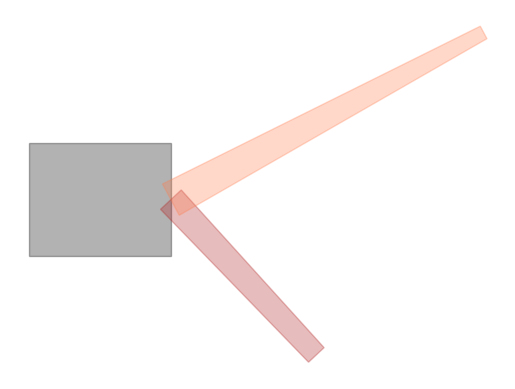

-----------------------------------
root         | soma
n_branches   | 3
geometry     | incomplete 3d points
length       | 100.00 * umetre
area         | 1885.25 * umeter2
volume       | 4822.34 * flitre
-----------------------------------

soma
├── basal
└── apical


In [2]:
tree = build_demo_morpho()
tree.vis2d()
print(tree)
print(tree.topo())


## 2. `Cell`: own a frozen morphology snapshot plus paint/place declarations

`Cell` is the frontend container that combines:

- a cloned `Morpho`
- one `CVPolicy`
- accumulated paint rules
- accumulated place rules
- lazily rebuilt derived structures such as `CV`, `PointTree`, and `PointScheduling`


In [3]:
cell_per_branch = Cell(tree, cv_policy=CVPolicy(cv_per_branch=2))
cell_by_length = Cell(
    tree,
    cv_policy=CVPolicy(mode="max_cv_len", max_cv_len=15.0 * u.um),
)
print(cell_per_branch)
print(cell_by_length)
{
    "cv_per_branch_counts": cv_counts_by_branch(cell_per_branch),
    "max_cv_len_counts": cv_counts_by_branch(cell_by_length),
}


-----------------------------------
root           | soma
n_branches     | 3
n_cv           | 6
n_paint_rules  | 1
n_place_rules  | 0
-----------------------------------

-----------------------------------
root           | soma
n_branches     | 3
n_cv           | 8
n_paint_rules  | 1
n_place_rules  | 0
-----------------------------------



{'cv_per_branch_counts': {0: 2, 1: 2, 2: 2},
 'max_cv_len_counts': {0: 2, 1: 2, 2: 4}}

## 3. `CV`: inspect one control volume at a time

Each `CV` stores geometry, topology, cable parameters, attached density mechanisms, and attached point mechanisms.

`Cell.cvs` returns the full tuple, and `Cell.cvs[i]` is the standard way to inspect one control volume.


In [4]:
print(cell_per_branch.cvs[0])
cell_per_branch.cvs

CV(id=0, branch_id=0, branch_type='soma', prox=0.0, dist=0.5, parent_cv=None, children_cv=(1,), length=10. * umetre, area=502.65482 * umeter2, cm=1. * ufarad / cmeter2, ra=100. * ohm * cmetre, v=-65. * mvolt, temp=309.15 * kelvin, r_axial=49735.918 * ohm, r_axial_prox=24867.959 * ohm, r_axial_dist=24867.959 * ohm, density_mech=(), point_mech=(), _frusta=(CVFrustum(prox=0.0, dist=0.5, length=10. * umetre, radius_prox=8. * umetre, radius_dist=8. * umetre, point_prox=None, point_dist=None),))


(CV(id=0, branch_id=0, branch_type='soma', prox=0.0, dist=0.5, parent_cv=None, children_cv=(1,), length=10. * umetre, area=502.65482 * umeter2, cm=1. * ufarad / cmeter2, ra=100. * ohm * cmetre, v=-65. * mvolt, temp=309.15 * kelvin, r_axial=49735.918 * ohm, r_axial_prox=24867.959 * ohm, r_axial_dist=24867.959 * ohm, density_mech=(), point_mech=(), _frusta=(CVFrustum(prox=0.0, dist=0.5, length=10. * umetre, radius_prox=8. * umetre, radius_dist=8. * umetre, point_prox=None, point_dist=None),)),
 CV(id=1, branch_id=0, branch_type='soma', prox=0.5, dist=1.0, parent_cv=0, children_cv=(2, 4), length=10. * umetre, area=502.65482 * umeter2, cm=1. * ufarad / cmeter2, ra=100. * ohm * cmetre, v=-65. * mvolt, temp=309.15 * kelvin, r_axial=49735.918 * ohm, r_axial_prox=24867.959 * ohm, r_axial_dist=24867.959 * ohm, density_mech=(), point_mech=(), _frusta=(CVFrustum(prox=0.5, dist=1.0, length=10. * umetre, radius_prox=8. * umetre, radius_dist=8. * umetre, point_prox=None, point_dist=None),)),
 CV(id=

## 4. `PaintRule` and `PlaceRule`: declare mechanisms on top of the CV geometry

`Cell.paint(...)` normalizes region-based declarations into `PaintRule` objects.
`Cell.place(...)` normalizes locset-based declarations into `PlaceRule` objects.

The rebuild step then maps those rules onto individual `CV` objects.


In [5]:
cell_per_branch.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    CableProperties(
        resting_potential=-70.0 * u.mV,
        membrane_capacitance=2.0 * (u.uF / u.cm ** 2),
        axial_resistivity=150.0 * (u.ohm * u.cm),
        temperature=u.celsius2kelvin(30.0),
    ),
)
cell_per_branch.paint_rules
cell_per_branch.cvs

(CV(id=0, branch_id=0, branch_type='soma', prox=0.0, dist=0.5, parent_cv=None, children_cv=(1,), length=10. * umetre, area=502.65482 * umeter2, cm=2. * ufarad / cmeter2, ra=150. * ohm * cmetre, v=-70. * mvolt, temp=303.15 * kelvin, r_axial=74603.88 * ohm, r_axial_prox=37301.94 * ohm, r_axial_dist=37301.94 * ohm, density_mech=(), point_mech=(), _frusta=(CVFrustum(prox=0.0, dist=0.5, length=10. * umetre, radius_prox=8. * umetre, radius_dist=8. * umetre, point_prox=None, point_dist=None),)),
 CV(id=1, branch_id=0, branch_type='soma', prox=0.5, dist=1.0, parent_cv=0, children_cv=(2, 4), length=10. * umetre, area=502.65482 * umeter2, cm=2. * ufarad / cmeter2, ra=150. * ohm * cmetre, v=-70. * mvolt, temp=303.15 * kelvin, r_axial=74603.88 * ohm, r_axial_prox=37301.94 * ohm, r_axial_dist=37301.94 * ohm, density_mech=(), point_mech=(), _frusta=(CVFrustum(prox=0.5, dist=1.0, length=10. * umetre, radius_prox=8. * umetre, radius_dist=8. * umetre, point_prox=None, point_dist=None),)),
 CV(id=2, bra

In [6]:
cell_per_branch.paint(
    BranchSlice(branch_index=1, prox=0.0, dist=1.0),
    DensityMechanism(
        channel_type="leaky",
        params=(("g_max", 4.0 * (u.mS / u.cm ** 2)),),
    ),
)
cell_per_branch.place(
    RootLocation(x=0.75),
    CurrentClamp(
        amplitude=0.1 * u.nA,
        delay=1.0 * u.ms,
        duration=2.0 * u.ms,
    ),
)
cell_per_branch.paint_rules
cell_per_branch.cvs

(CV(id=0, branch_id=0, branch_type='soma', prox=0.0, dist=0.5, parent_cv=None, children_cv=(1,), length=10. * umetre, area=502.65482 * umeter2, cm=2. * ufarad / cmeter2, ra=150. * ohm * cmetre, v=-70. * mvolt, temp=303.15 * kelvin, r_axial=74603.88 * ohm, r_axial_prox=37301.94 * ohm, r_axial_dist=37301.94 * ohm, density_mech=(), point_mech=(), _frusta=(CVFrustum(prox=0.0, dist=0.5, length=10. * umetre, radius_prox=8. * umetre, radius_dist=8. * umetre, point_prox=None, point_dist=None),)),
 CV(id=1, branch_id=0, branch_type='soma', prox=0.5, dist=1.0, parent_cv=0, children_cv=(2, 4), length=10. * umetre, area=502.65482 * umeter2, cm=2. * ufarad / cmeter2, ra=150. * ohm * cmetre, v=-70. * mvolt, temp=303.15 * kelvin, r_axial=74603.88 * ohm, r_axial_prox=37301.94 * ohm, r_axial_dist=37301.94 * ohm, density_mech=(), point_mech=(CurrentClamp(amplitude=0.1 * namp, delay=1. * msecond, duration=2. * msecond),), _frusta=(CVFrustum(prox=0.5, dist=1.0, length=10. * umetre, radius_prox=8. * umetre

## 5. `PointTree`: convert CVs into compute points and edges

`PointTree` is the next derived structure.
It expands each `CV` into midpoint and endpoint roles, then records the compute graph as `ComputePoint` and `ComputeEdge` objects.


In [11]:
point_tree = cell_per_branch.point_tree()
print(cell_by_length)
{
    "cv_midpoint_point_id": point_tree.cv_midpoint_point_id.tolist(),
    "branch_terminal_point_id": point_tree.branch_terminal_point_id.tolist(),
}

-----------------------------------
root           | soma
n_branches     | 3
n_cv           | 8
n_paint_rules  | 1
n_place_rules  | 0
-----------------------------------



{'cv_midpoint_point_id': [1, 2, 4, 5, 7, 8],
 'branch_terminal_point_id': [3, 6, 9]}

## 6. `PointScheduling`: assign point rows and execution groups

`PointScheduling` takes a `PointTree` and computes a row order together with peel-level groups.

This is the structure that downstream kernels can use to process points level by level.


In [13]:
scheduling = cell_per_branch.point_scheduling(max_group_size=2)
{
    "row_to_point_id": scheduling.row_to_point_id.tolist(),
    "point_id_to_row": scheduling.point_id_to_row.tolist(),
    "groups": [group.tolist() for group in scheduling.groups],
    "level_size": scheduling.level_size.tolist(),
    "level_start": scheduling.level_start.tolist(),
}

{'row_to_point_id': [0, 1, 2, 3, 4, 7, 5, 8, 6, 9],
 'point_id_to_row': [0, 1, 2, 3, 4, 6, 8, 5, 7, 9],
 'groups': [[0], [1], [2], [3], [4, 5], [6, 7], [8, 9]],
 'level_size': [1, 1, 1, 1, 2, 2, 2],
 'level_start': [0, 1, 2, 3, 4, 6, 8]}

## Recap

The class chain in `braincell.cell` is:

- `Morpho` + `CVPolicy` -> `Cell`
- `Cell` rebuild -> `CV` objects
- `Cell.point_tree()` -> `PointTree`
- `Cell.point_scheduling(...)` -> `PointScheduling`

That makes `Cell` the main user-facing assembly point, while the other classes expose progressively more execution-oriented views of the same model.
